<a href="https://colab.research.google.com/github/gilvylanggawan11/CodeBlueThreatHunting/blob/main/Trial_Ask_All_process_to_gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cyber Forensic Investigation for Enterprise Attack Logs**

This notebook demonstrates a reproducible cyber forensic investigation workflow for analyzing enterprise security logs

Main objectives:
- Load and preprocess enterprise log datasets
- Analyze attack vs benign activities
- Reconstruct attack timelines
- Identify lateral movement behavior
- Evaluate detection performance
- Generate forensic insights

# **Dataset Loading and Preparation (Log Ingestion)**</br>
Cyber forensic analysts should first download the enterprise security log dataset from the provided Google Drive link and upload the compressed ZIP file into the Google Colab environment. The dataset contains multiple JSON log files representing enterprise security events.

The notebook then extracts the ZIP archive, reads each JSON log entry line-by-line, and converts the logs into a structured Pandas DataFrame for analysis.

After loading the dataset, the system reports the total number of log records available for analysis.

Enterprise Attack Logs dataset : [Link ](https://drive.google.com/file/d/1-AhyWxekA0-QF5z7s8zri89ewLhODa9e/view?usp=drive_link)

In [2]:
!pip install -U --no-cache-dir gdown
import gdown

# Google Drive file ID from the provided link
file_id = '1-AhyWxekA0-QF5z7s8zri89ewLhODa9e'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'enterprise_logs.zip'

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1-AhyWxekA0-QF5z7s8zri89ewLhODa9e
To: /content/enterprise_logs.zip
100%|██████████| 16.9M/16.9M [00:00<00:00, 109MB/s]


'enterprise_logs.zip'

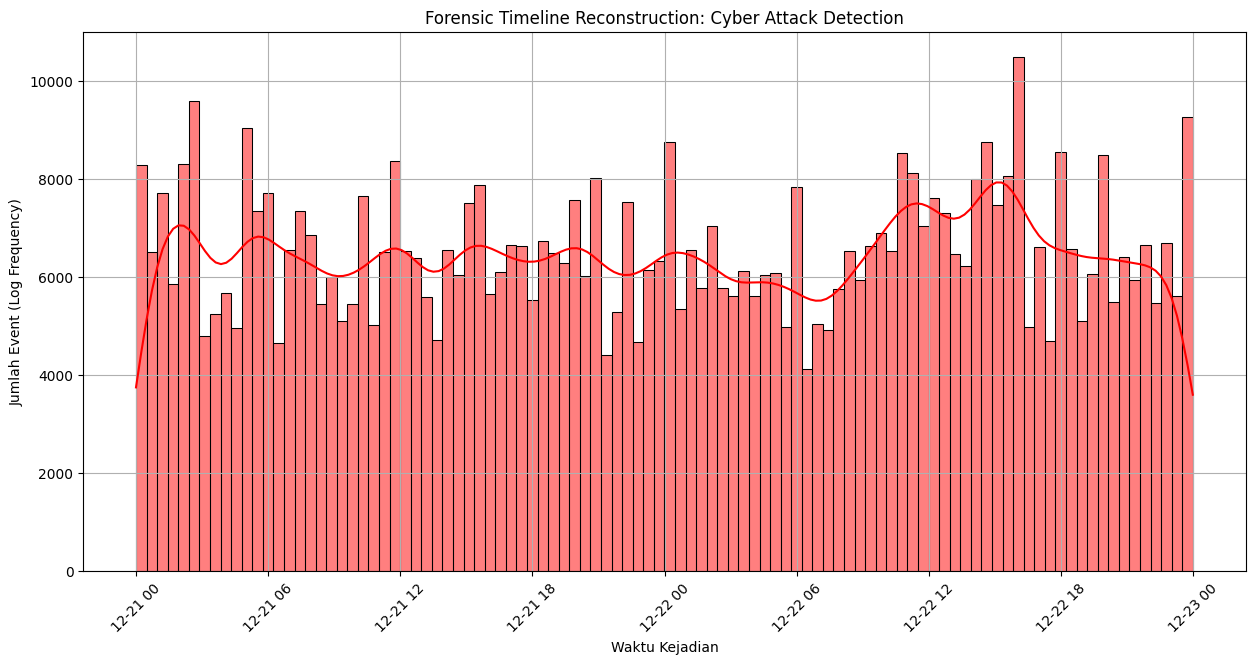

Total log events yang dianalisis: 653669

--- Alur Kejadian (Attack Sequence) ---


,timestamp,event_type,user,hostname,process_name,command_line,source_ip,destination_ip
526290,2025-12-21,ntlm_auth_success,svc_mysql_backup,DB-SRV-01,mysqldump.exe,Authenticate MySQL backup to database server,10.1.50.75,NaN
526267,2025-12-21,database_query,svc_sql_analysis,DB-SRV-03,msmdsrv.exe,DirectQuery mode data access,10.2.50.75,10.2.50.75
526268,2025-12-21,system_event,svc_sql_analysis,DB-SRV-03,msmdsrv.exe,Server resource utilization check,10.2.50.75,10.2.50.50
526269,2025-12-21,admin_action,svc_sql_analysis,DB-SRV-04,msmdsrv.exe,Multi-language caption processing,10.2.50.76,10.2.50.76
526270,2025-12-21,file_create,svc_sql_analysis,DB-SRV-04,msmdsrv.exe,Analysis Services database backup,10.2.50.76,10.2.50.200
526271,2025-12-21,database_query,svc_sql_analysis,DB-SRV-06,msmdsrv.exe,Tabular model DAX query,10.3.50.76,10.3.50.75
526272,2025-12-21,system_event,svc_sql_analysis,DB-SRV-06,msmdsrv.exe,Query performance statistics,10.3.50.76,NaN
526273,2025-12-21,login_attempt,svc_sql_analysis,DB-SRV-01,msmdsrv.exe,Analysis Services user authentication,10.1.50.75,10.1.50.75
526274,2025-12-21,system_event,svc_sql_analysis,DB-SRV-01,msmdsrv.exe,Analysis Services memory usage check,10.1.50.75,10.1.50.76
526275,2025-12-21,database_query,svc_sql_analysis,DB-SRV-01,msmdsrv.exe,MDX query execution,10.1.50.75,10.1.50.76



--- Koneksi Jaringan Terdeteksi ---


,source_ip,destination_ip,count
10282,10.2.50.10,10.2.50.10,3743
15630,10.3.50.10,10.3.50.10,3687
4314,10.1.50.10,10.1.50.10,3662
4661,10.1.50.5,10.1.50.5,3428
10564,10.2.50.5,10.2.50.5,3348
15758,10.3.50.5,10.3.50.5,3263
15843,10.3.50.76,10.3.50.75,2731
4879,10.1.50.75,10.1.50.75,2704
4880,10.1.50.75,10.1.50.76,2683
4901,10.1.50.76,10.1.50.75,2679


In [7]:
import pandas as pd
import json
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pastikan ekstraksi data benar
zip_path = 'enterprise_logs.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('logs_data')

# 2. Load Logs secara rekursif
log_entries = []
log_dir = 'logs_data'
for root, dirs, files in os.walk(log_dir):
    for filename in files:
        if filename.endswith('.json'):
            with open(os.path.join(root, filename), 'r') as f:
                for line in f:
                    try:
                        log_entries.append(json.loads(line))
                    except:
                        continue

df = pd.DataFrame(log_entries)

# 3. Preprocessing dan Timeline Reconstruction
if not df.empty and 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(by='timestamp')

    # Visualisasi Timeline
    plt.figure(figsize=(15, 7))
    sns.histplot(data=df, x='timestamp', bins=100, kde=True, color='red')
    plt.title('Forensic Timeline Reconstruction: Cyber Attack Detection')
    plt.xlabel('Waktu Kejadian')
    plt.ylabel('Jumlah Event (Log Frequency)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

    print(f"Total log events yang dianalisis: {len(df)}")

    # Identifikasi anomali/lonjakan
    print("\n--- Alur Kejadian (Attack Sequence) ---")
    # Menampilkan kolom kunci untuk investigasi forensic
    cols = ['timestamp', 'event_type', 'user', 'hostname', 'process_name', 'command_line', 'source_ip', 'destination_ip']
    display_cols = [c for c in cols if c in df.columns]
    display(df[display_cols].head(20))

    # Analisis lateral movement jika ada data IP
    if 'source_ip' in df.columns and 'destination_ip' in df.columns:
        print("\n--- Koneksi Jaringan Terdeteksi ---")
        network_flow = df.groupby(['source_ip', 'destination_ip']).size().reset_index(name='count').sort_values(by='count', ascending=False)
        display(network_flow.head(10))
else:
    print("Data tidak ditemukan atau kolom 'timestamp' tidak ada. Pastikan file JSON sudah benar.")
    if not df.empty: print("Kolom yang tersedia:", df.columns.tolist())

### **Deep Dive: Analysis of the Attack Peak**
In this step, we identify the exact moment the attack reached its maximum intensity and analyze the specific event types occurring during that window.

In [8]:
# 1. Identify the peak timestamp (using a 1-minute window for precision)
if not df.empty:
    peak_time = df.set_index('timestamp').resample('1min').size().idxmax()
    print(f"Peak attack activity detected at: {peak_time}")

    # 2. Filter data around the peak (e.g., +/- 2 minutes)
    buffer = pd.Timedelta(minutes=2)
    peak_df = df[(df['timestamp'] >= peak_time - buffer) & (df['timestamp'] <= peak_time + buffer)]

    print(f"\n--- Top Event Types at Peak ({len(peak_df)} events) ---")
    display(peak_df['event_type'].value_counts().head(10))

    print("\n--- Top Users Involved at Peak ---")
    display(peak_df['user'].value_counts().head(10))

    print("\n--- Sample of Critical Commands/Processes at Peak ---")
    peak_cols = ['timestamp', 'event_type', 'user', 'process_name', 'command_line', 'source_ip']
    display_peak = [c for c in peak_cols if c in peak_df.columns]
    display(peak_df[display_peak].head(15))
else:
    print("DataFrame is empty. Please ensure the logs are loaded correctly.")

Peak attack activity detected at: 2025-12-21 01:20:00

--- Top Event Types at Peak (1868 events) ---


,count
event_type,
network_connection,551
admin_action,506
file_access,222
system_event,138
process_start,67
file_create,66
database_query,65
registry_access,60
login_attempt,36



--- Top Users Involved at Peak ---


,count
user,
svc_edr_agent,461
svc_antivirus,403
svc_siem_activity,399
svc_siem_collector,225
svc_compliance_audit,33
svc_mysql_backup,32
svc_sql_analysis,30
svc_vulnerability_scan,28
svc_database,28



--- Sample of Critical Commands/Processes at Peak ---


,timestamp,event_type,user,process_name,command_line,source_ip
546598,2025-12-21 01:18:00,network_connection,svc_network_security,paloalto.exe,QoS policy applied to traffic,10.2.50.5
546610,2025-12-21 01:18:00,system_event,svc_erp_connector,idocprocessor.exe,IDOC inbound message processing,10.3.50.60
546611,2025-12-21 01:18:00,network_connection,svc_erp_connector,rfc.exe,Fixed asset register update,10.3.50.60
546612,2025-12-21 01:18:00,database_query,svc_erp_connector,sapconnector.exe,Manufacturing order synchronization,10.2.50.60
546615,2025-12-21 01:18:00,scheduled_task,svc_erp_connector,sapconnector.exe,Automated ERP synchronization job initiated,10.2.50.61
546614,2025-12-21 01:18:00,scheduled_task,svc_erp_connector,sapconnector.exe,Automated ERP synchronization job initiated,10.2.50.60
546609,2025-12-21 01:18:00,network_connection,svc_erp_connector,sapconnector.exe,SAP RFC connection validation completed,10.3.50.60
546613,2025-12-21 01:18:00,database_query,svc_erp_connector,sapconnector.exe,Cost center hierarchy update,10.2.50.60
546608,2025-12-21 01:18:00,network_connection,svc_erp_connector,sapconnector.exe,Project system cost synchronization,10.3.50.60
546604,2025-12-21 01:18:00,system_event,svc_erp_connector,rfc.exe,ERP batch job status check completed,10.1.50.61


### **Reconstruction of the Attack Lifecycle**
We will now categorize events into standard cyber forensic stages to understand the flow of the attack.

In [9]:
import pandas as pd

# Mendefinisikan indikator serangan berdasarkan temuan sebelumnya
suspicious_keywords = ['mysqldump', 'ntlm_auth_success', 'break glass', 'privileged_access', 'unauthorized']

# 1. Filter log yang mengandung aktivitas mencurigakan
attack_flow = df[df['command_line'].str.contains('|'.join(suspicious_keywords), case=False, na=False) |
                df['event_type'].str.contains('login_attempt|admin_action', case=False, na=False)]

# 2. Urutkan berdasarkan waktu
attack_flow = attack_flow.sort_values('timestamp')

print("--- Alur Kronologis Serangan ---")
display_cols = ['timestamp', 'hostname', 'user', 'event_type', 'process_name', 'command_line']
display(attack_flow[display_cols].head(30))

# 3. Analisis Host Terbanyak yang Terkena Dampak
print("\n--- Host dengan Aktivitas Mencurigakan Tertinggi ---")
display(attack_flow['hostname'].value_counts().head(5))

--- Alur Kronologis Serangan ---


,timestamp,hostname,user,event_type,process_name,command_line
526269,2025-12-21 00:00:00,DB-SRV-04,svc_sql_analysis,admin_action,msmdsrv.exe,Multi-language caption processing
526266,2025-12-21 00:00:00,DB-SRV-02,svc_sql_analysis,admin_action,msmdsrv.exe,Dimension security validation
526265,2025-12-21 00:00:00,DB-SRV-02,svc_sql_analysis,admin_action,msmdsrv.exe,Multi-language caption processing
526287,2025-12-21 00:00:00,SEC-SRV-01,svc_privileged_access,admin_action,thycotic.exe,Third-party vendor access provisioned
526285,2025-12-21 00:00:00,SEC-SRV-01,svc_privileged_access,admin_action,thycotic.exe,Emergency break glass access initiated
526284,2025-12-21 00:00:00,SEC-SRV-01,svc_privileged_access,admin_action,hashicorp.exe,Application API key automatically rotated
526288,2025-12-21 00:00:00,SEC-SRV-01,svc_privileged_access,admin_action,cyberark.exe,Unauthorized privilege escalation detected
526282,2025-12-21 00:00:00,SEC-SRV-02,svc_privileged_access,admin_action,cyberark.exe,Privileged session recorded for audit
526280,2025-12-21 00:00:00,SEC-SRV-03,svc_privileged_access,admin_action,beyondtrust.exe,Administrative session monitored for compliance
526279,2025-12-21 00:00:00,SEC-SRV-03,svc_privileged_access,admin_action,cyberark.exe,Privileged session recorded for audit



--- Host dengan Aktivitas Mencurigakan Tertinggi ---


,count
hostname,
FW-01,2544
CSPM-02,2535
CSPM-01,2531
FW-02,2516
FW-03,2453


### **Attack Phase Distribution Over Time**
We will categorize the suspicious events into forensic phases and visualize their occurrence frequency across the investigation timeline.

/tmp/ipykernel_8093/3939487185.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Attack Phase', bbox_to_anchor=(1.05, 1), loc='upper left')


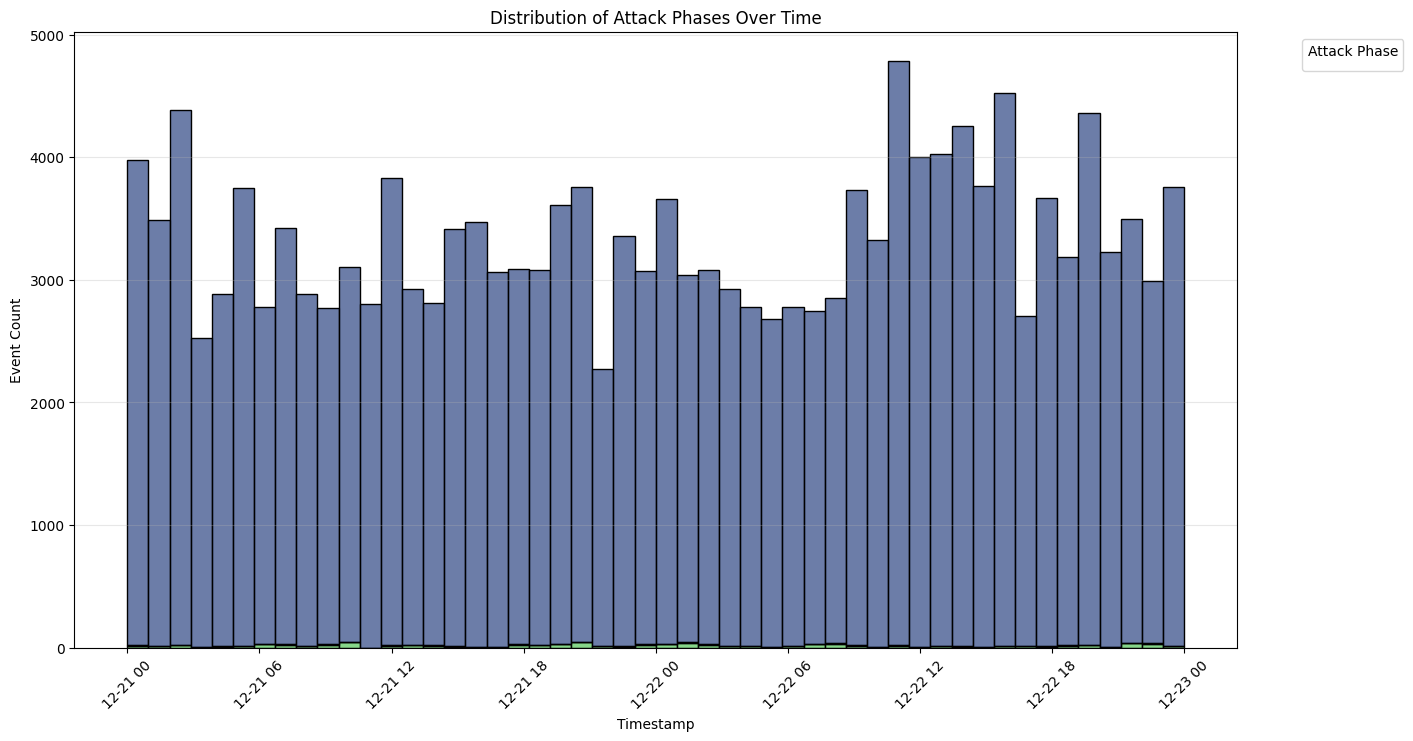


--- Summary of Events per Attack Phase ---


,count
attack_phase,
5. Other Suspicious Activity,165848
2. Infrastructure Manipulation,871
1. Privilege Escalation,143


In [10]:
def categorize_phase(row):
    cmd = str(row['command_line']).lower()
    evt = str(row['event_type']).lower()
    if 'break glass' in cmd or 'privileged_access' in cmd:
        return '1. Privilege Escalation'
    elif 'terraform' in cmd or 'sentinel' in cmd or 'checkov' in cmd:
        return '2. Infrastructure Manipulation'
    elif 'mysqldump' in cmd or 'database_query' in evt:
        return '3. Data Staging/Exfiltration'
    elif 'network_connection' in evt:
        return '4. Lateral Movement'
    else:
        return '5. Other Suspicious Activity'

if not attack_flow.empty:
    # Apply categorization
    attack_flow['attack_phase'] = attack_flow.apply(categorize_phase, axis=1)

    # Visualization
    plt.figure(figsize=(15, 8))
    sns.histplot(data=attack_flow, x='timestamp', hue='attack_phase',
                 bins=50, multiple='stack', palette='viridis')
    plt.title('Distribution of Attack Phases Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Event Count')
    plt.legend(title='Attack Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Display summary count per phase
    print("\n--- Summary of Events per Attack Phase ---")
    display(attack_flow['attack_phase'].value_counts())
else:
    print("Attack flow data is empty.")

### **Targeted Hostnames: Infrastructure Manipulation Phase**
We will analyze which specific hosts were most frequently targeted during the infrastructure manipulation stage (Terraform, Sentinel, etc.).

--- Targeted Hostnames during Infrastructure Manipulation (871 events) ---


,Hostname,Event Count
0,AUTO-SRV-02,285
1,AUTO-SRV-03,242
2,AUTO-SRV-01,238
3,BUILD-SRV-01,54
4,BUILD-SRV-02,52


/tmp/ipykernel_8093/3940000193.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=infra_hosts.head(15), x='Event Count', y='Hostname', palette='rocket')


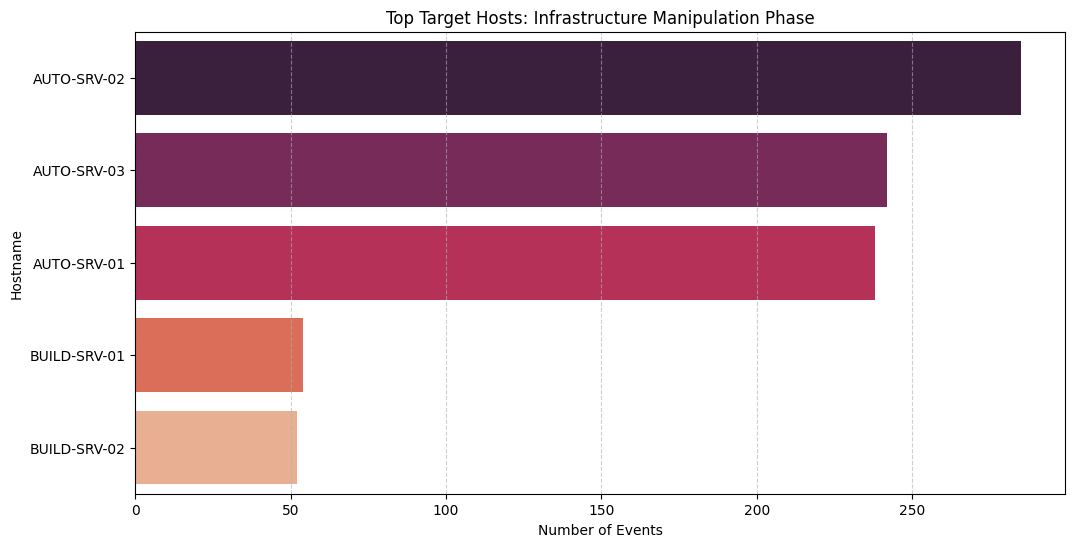

In [11]:
if not attack_flow.empty:
    # Filter for Infrastructure Manipulation
    infra_manip_df = attack_flow[attack_flow['attack_phase'] == '2. Infrastructure Manipulation']

    print(f"--- Targeted Hostnames during Infrastructure Manipulation ({len(infra_manip_df)} events) ---")
    infra_hosts = infra_manip_df['hostname'].value_counts().reset_index()
    infra_hosts.columns = ['Hostname', 'Event Count']
    display(infra_hosts)

    # Visualizing the targets
    plt.figure(figsize=(12, 6))
    sns.barplot(data=infra_hosts.head(15), x='Event Count', y='Hostname', palette='rocket')
    plt.title('Top Target Hosts: Infrastructure Manipulation Phase')
    plt.xlabel('Number of Events')
    plt.ylabel('Hostname')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()
else:
    print('Attack flow data is not available.')

**If the dataset is successfully loaded, the system will display the total number of log events that have been imported into the dataframe for analysis.*